<a href="https://colab.research.google.com/github/SAIOMKAR1919/AML/blob/main/StudentGradeAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset loaded successfully
first 5 rows:
   SEM 1  SEM 2  SEM 3  SEM 4  SEM 5
0   6.60   7.60   6.90   7.22   7.08
1   7.77   7.22   7.00   7.90   7.47
2   6.90   6.00   7.12   7.54   6.89
3   5.50   6.60   6.70   6.50   6.33
4   7.20   6.00   7.21   7.70   7.03

 Dataset shape:
(379, 5)
Column names:
Index(['SEM 1', 'SEM 2', 'SEM 3', 'SEM 4', 'SEM 5'], dtype='object')

 Informtions:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 379 entries, 0 to 378
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SEM 1   379 non-null    float64
 1   SEM 2   379 non-null    float64
 2   SEM 3   379 non-null    float64
 3   SEM 4   379 non-null    float64
 4   SEM 5   379 non-null    float64
dtypes: float64(5)
memory usage: 14.9 KB
None
Missing values:
SEM 1    0
SEM 2    0
SEM 3    0
SEM 4    0
SEM 5    0
dtype: int64
Target variable: SEM 5
          SEM 1     SEM 2     SEM 3     SEM 4     SEM 5
SEM 1  1.000000  0.976568  0.968651  0.9

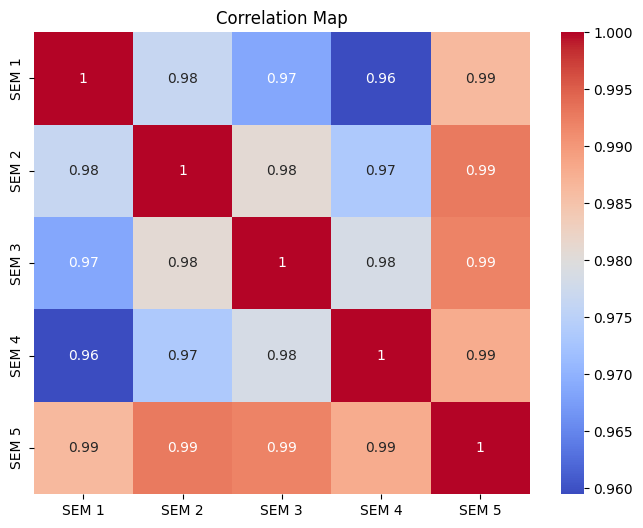

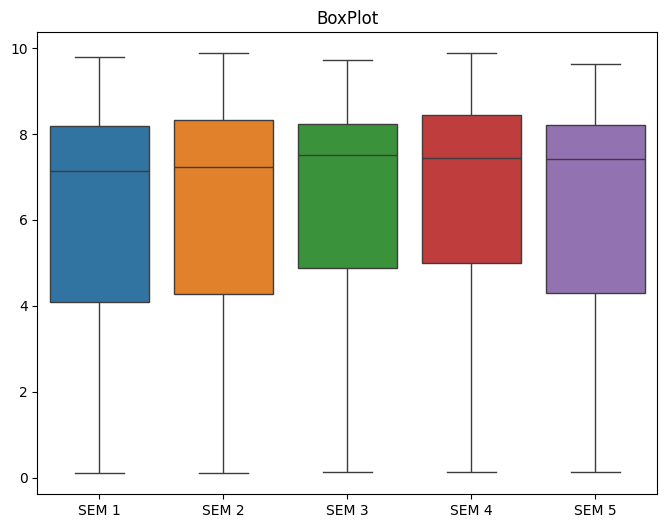

Simple Linear Regression:
MAE:  0.3556793732530752
MSE:  0.22840107560400197
RMSE:  0.47791325112827954
R2 Score:  0.9780402957252133


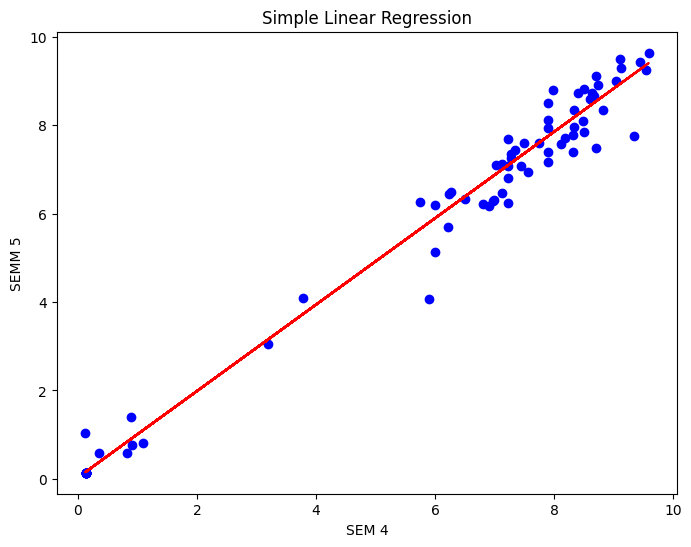

Multiple Linear Regression:
MAE : 0.0023391696650216596
MSE : 7.162756055514429e-06
RMSE : 0.00267633257565543
R2 Score : 0.9999993113342205
  Features  Coefficient
0    SEM 1     0.249850
1    SEM 2     0.250249
2    SEM 3     0.249938
3    SEM 4     0.249665


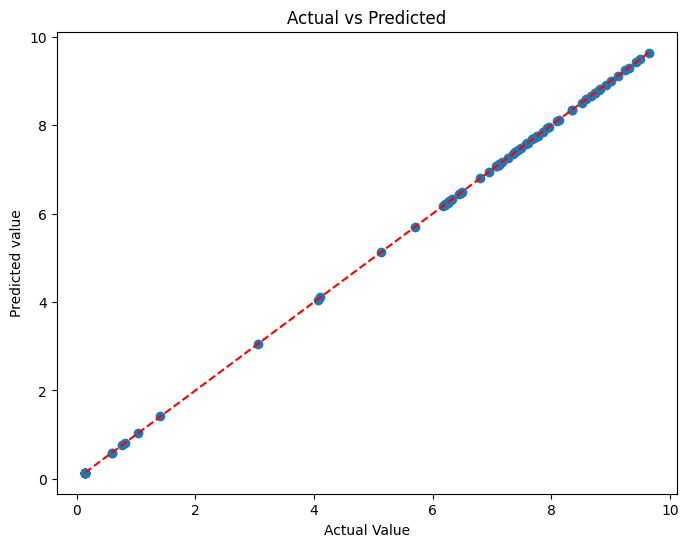

Intercept:  0.0035713111292468014


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

df = pd.read_excel("/content/cgpaPRED.xls")
print("Dataset loaded successfully")

print("first 5 rows:")
print(df.head())

print("\n Dataset shape:")
print(df.shape)

print("Column names:")
print(df.columns)

print("\n Informtions:")
print(df.info())

print("Missing values:")
print(df.isnull().sum())

label = "SEM 5"
print("Target variable:",label)

corr = df.corr(numeric_only = True)
print(corr)

print(corr["SEM 5"].sort_values(ascending = False))

plt.figure(figsize = (8,6))
sns.heatmap(
    corr,
    annot = True,
    cmap = "coolwarm"
)
plt.title("Correlation Map")
plt.show

plt.figure(figsize = (8,6))
sns.boxplot(data = df)
plt.title("BoxPlot")
plt.show()

X = df[["SEM 4"]]
y = df["SEM 5"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

model = LinearRegression()
model.fit(X_train,y_train)

pred = model.predict(X_test)

print("Simple Linear Regression:")
print("MAE: ",mean_absolute_error(y_test,pred))
print("MSE: ",mean_squared_error(y_test,pred))
print("RMSE: ",np.sqrt(mean_squared_error(y_test,pred)))
print("R2 Score: ",r2_score(y_test,pred))

plt.figure(figsize = (8,6))
plt.scatter(X_test,y_test,color = 'blue')
plt.plot(X_test,pred,color = "red")
plt.xlabel("SEM 4")
plt.ylabel("SEMM 5")
plt.title("Simple Linear Regression")
plt.show()

X = df[["SEM 1","SEM 2","SEM 3","SEM 4"]]
y = df["SEM 5"]

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size = 0.20,
    random_state =42
)

mlr = LinearRegression()
mlr.fit(X_train,y_train)

prediction = mlr.predict(X_test)

print("Multiple Linear Regression:")
print("MAE :", mean_absolute_error(y_test,prediction))
print("MSE :", mean_squared_error(y_test,prediction))
print("RMSE :", np.sqrt(mean_squared_error(y_test,prediction)))
print("R2 Score :", r2_score(y_test,prediction))

coef  = pd.DataFrame({
    "Features":X.columns,
    "Coefficient": mlr.coef_
})
print(coef)

plt.figure(figsize = (8,6))
plt.scatter(y_test,prediction)
plt.plot(
    [y_test.min(),y_test.max()],
    [y_test.min(),y_test.max()],
    'r--'
)
plt.xlabel("Actual Value")
plt.ylabel("Predicted value")
plt.title("Actual vs Predicted")
plt.show()

print("Intercept: ",mlr.intercept_)